In [29]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

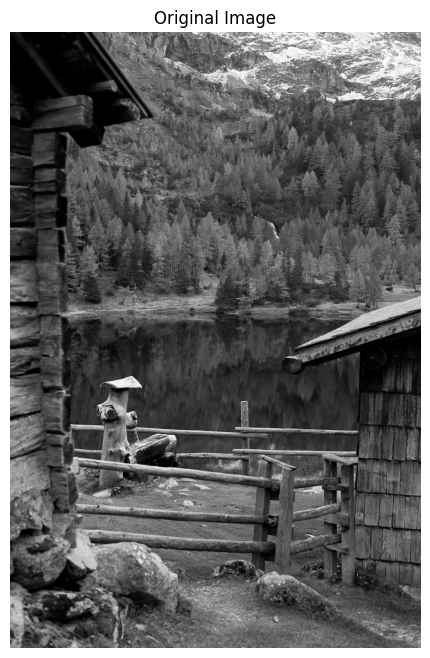

In [30]:
# Load the original image
img = cv2.imread('pexels-michael-fischer-2156849519-34408249.jpg', 0)

# Display the original image
plt.figure(figsize=(10, 8))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

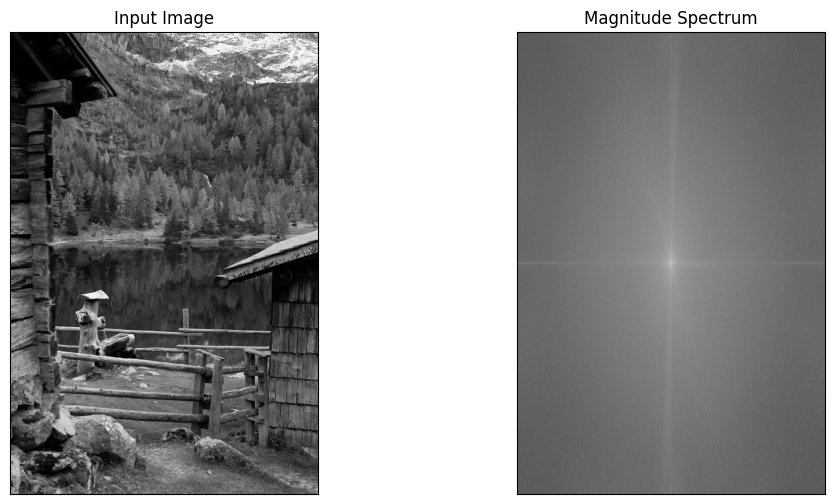

In [31]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1) # Added +1 to avoid log(0)

plt.figure(figsize=(12, 6))
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

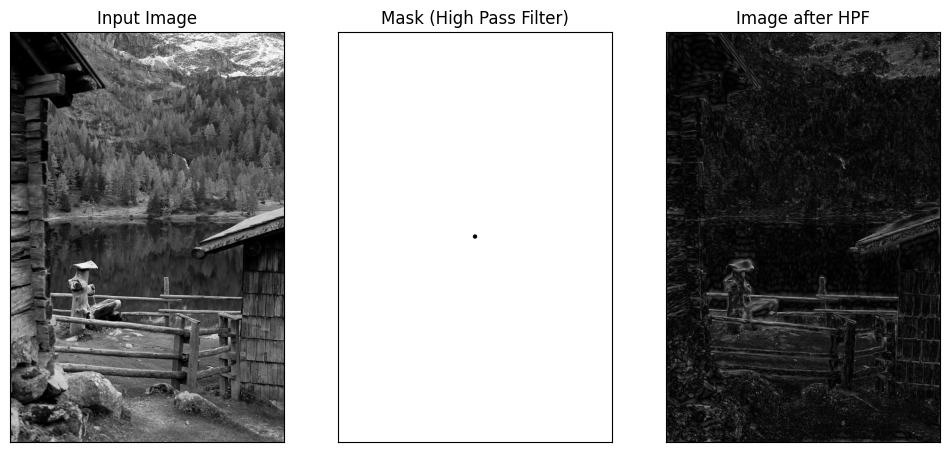

In [32]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# High Pass Filter - High Frequency allowed, Low Frequency blocked
# Create a mask with center square is 0, remaining all ones
mask = np.ones((rows, cols), np.uint8)
r = 30
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r*r
mask[mask_area] = 0

# Apply mask and inverse DFT
fshift_filtered = fshift * mask
f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(131),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])

plt.subplot(132),plt.imshow(mask, cmap = 'gray')
plt.title('Mask (High Pass Filter)'), plt.xticks([]), plt.yticks([])

plt.subplot(133),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after HPF'), plt.xticks([]), plt.yticks([])

plt.show()

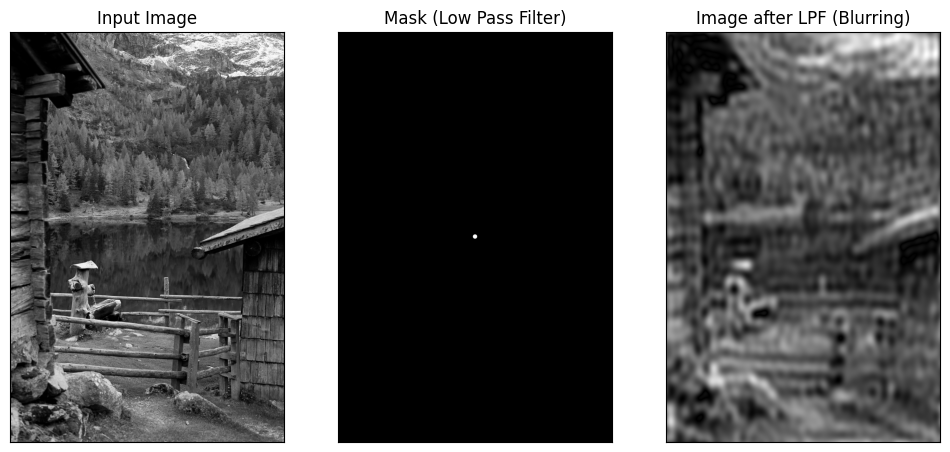

In [33]:
# Low Pass Filter - Low Frequency allowed, High Frequency blocked
# Create a mask with center square is 1, remaining all zeros
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
mask_lpf = np.zeros((rows, cols), np.uint8)
r = 30
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = ( (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r*r )
mask_lpf[mask_area] = 1

# Apply mask and inverse DFT
fshift_filtered_lpf = fshift * mask_lpf
f_ishift_lpf = np.fft.ifftshift(fshift_filtered_lpf)
img_back_lpf = np.fft.ifft2(f_ishift_lpf)
img_back_lpf = np.abs(img_back_lpf)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(131),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])

plt.subplot(132),plt.imshow(mask_lpf, cmap = 'gray')
plt.title('Mask (Low Pass Filter)'), plt.xticks([]), plt.yticks([])

plt.subplot(133),plt.imshow(img_back_lpf, cmap = 'gray')
plt.title('Image after LPF (Blurring)'), plt.xticks([]), plt.yticks([])

plt.show()